In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import gym
from main.alpaca import *
from main.dataset import *
from main.dataViz import *
import yaml
import jax 
import jax.numpy as jnp

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
cfg_filename = 'configs/sinusoid-config.yml'
with open(cfg_filename,'r') as ymlfile:
    config = yaml.load(ymlfile, Loader=yaml.SafeLoader)

In [3]:
noise1 = 0.1
noise2 = 0.3
noise3 = 0.5
dataset1 = SinusoidDataset(config, noise_var=noise1, rng=np.random.RandomState(1234))
dataset2 = SinusoidDataset(config, noise_var=noise2, rng=np.random.RandomState(1234))
dataset3 = SinusoidDataset(config, noise_var=noise3, rng=np.random.RandomState(1234))

## Agents

In [ ]:
steps = 5000
config1 = config.copy()
config1["sigma_eps"] = noise1
agent1 = ALPaCAjax(config1)
# train_log1 = train_loop(agent1, dataset1, num_steps=steps)
agent1.eval()  # ready for evaluation/plotting

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int32[]
It arose in the jnp.arange argument 'stop'
This BatchTracer with object id 140675938575536 was created on line:
  /home/x_lab/workspace/roboracer/src/alpaca-repo/main/alpaca.py:160:29 (ALPaCAjax._blr_posterior)

See https://docs.jax.dev/en/latest/errors.html#jax.errors.ConcretizationTypeError

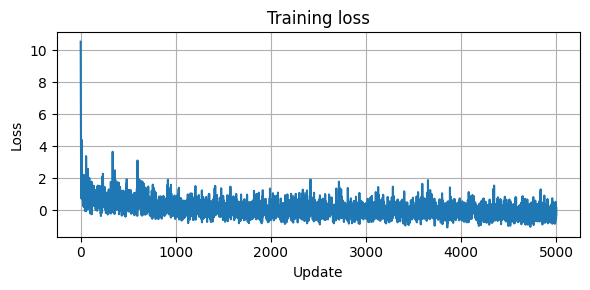

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(np.array(train_log1["loss_history"]))
plt.xlabel('Update')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
config2 = config.copy()
config2["sigma_eps"] = noise2
agent2 = ALPaCA(config2)
train_log2 = agent2.train_step(dataset2, num_train_updates=steps)
agent2.eval()

iter      0  loss: 3.648906  RMSE_1step: 2.122141  MPV_1step: 6.042424
iter     50  loss: 1.538993  RMSE_1step: 0.801671  MPV_1step: 1.812983
iter    100  loss: 2.073313  RMSE_1step: 1.026309  MPV_1step: 8.312758
iter    150  loss: 2.028557  RMSE_1step: 1.067820  MPV_1step: 1.837085
iter    200  loss: 1.911952  RMSE_1step: 1.736149  MPV_1step: 4.049264
iter    250  loss: 0.904530  RMSE_1step: 1.051233  MPV_1step: 1.027327
iter    300  loss: 1.363127  RMSE_1step: 1.033921  MPV_1step: 3.989549
iter    350  loss: 1.387768  RMSE_1step: 0.908452  MPV_1step: 1.931940
iter    400  loss: 1.013254  RMSE_1step: 0.727452  MPV_1step: 1.638383
iter    450  loss: 1.355280  RMSE_1step: 1.205161  MPV_1step: 2.852853
iter    500  loss: 1.053534  RMSE_1step: 0.754878  MPV_1step: 0.607194
iter    550  loss: 0.644130  RMSE_1step: 0.404040  MPV_1step: 1.269250
iter    600  loss: 1.032542  RMSE_1step: 0.623057  MPV_1step: 1.801215
iter    650  loss: 1.094369  RMSE_1step: 1.268509  MPV_1step: 1.664251
iter  

ALPaCA(
  (phi_net): MLP(
    (act): Tanh()
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=32, bias=True)
    )
  )
)

In [ ]:
config3 = config.copy()
config3["sigma_eps"] = noise3
agent3 = ALPaCA(config3)
train_log3 = agent3.train_step(dataset3, num_train_updates=steps)
agent3.eval()

iter      0  loss: 3.943541  RMSE_1step: 1.771420  MPV_1step: 16.423981
iter     50  loss: 1.794398  RMSE_1step: 1.305101  MPV_1step: 3.342051
iter    100  loss: 1.743859  RMSE_1step: 1.052037  MPV_1step: 1.599656
iter    150  loss: 2.313283  RMSE_1step: 1.378296  MPV_1step: 7.207279
iter    200  loss: 1.764405  RMSE_1step: 1.094496  MPV_1step: 2.308526
iter    250  loss: 1.336496  RMSE_1step: 1.372579  MPV_1step: 1.365763
iter    300  loss: 1.778868  RMSE_1step: 1.387843  MPV_1step: 2.192710
iter    350  loss: 1.218511  RMSE_1step: 0.609869  MPV_1step: 1.222150
iter    400  loss: 1.718823  RMSE_1step: 1.017344  MPV_1step: 2.141219
iter    450  loss: 1.223061  RMSE_1step: 1.364165  MPV_1step: 2.334319
iter    500  loss: 1.146139  RMSE_1step: 0.744184  MPV_1step: 1.734416
iter    550  loss: 1.464430  RMSE_1step: 0.728542  MPV_1step: 2.055943
iter    600  loss: 1.028807  RMSE_1step: 0.407472  MPV_1step: 1.463324
iter    650  loss: 1.037743  RMSE_1step: 0.848994  MPV_1step: 2.060799
iter 

ALPaCA(
  (phi_net): MLP(
    (act): Tanh()
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=32, bias=True)
    )
  )
)

# Visualize all agents

In [ ]:
N_test = 50
test_horz = 30
dataset1 = SinusoidDataset(config, noise_var=noise1, rng=np.random.RandomState(4321))
dataset2 = SinusoidDataset(config, noise_var=noise2, rng=np.random.RandomState(4321))
dataset3 = SinusoidDataset(config, noise_var=noise3, rng=np.random.RandomState(4321))
X_test1, Y_test1, freq_list_test, amp_list_test, phase_list_test = dataset1.sample(N_test, test_horz, return_lists=True)
X_test2, Y_test2 = dataset2.sample(N_test, test_horz, return_lists=False)
X_test3, Y_test3 = dataset3.sample(N_test, test_horz, return_lists=False)

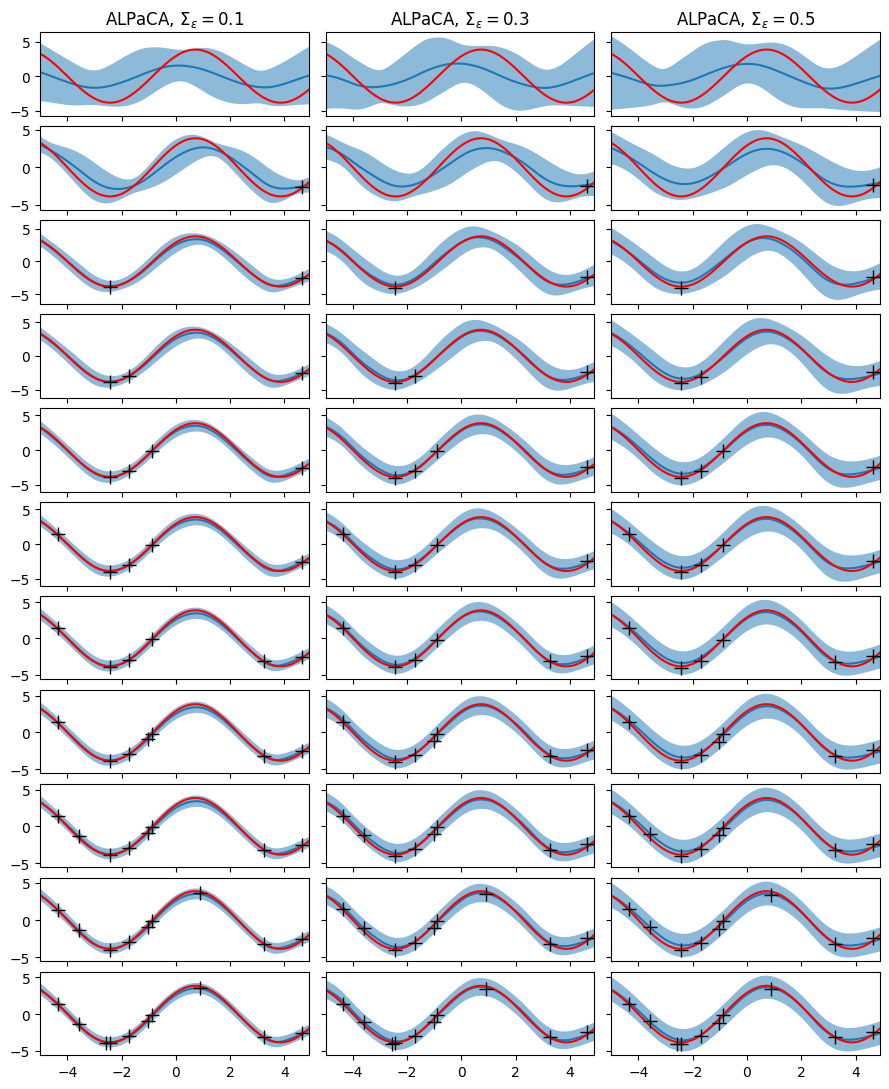

In [ ]:
ind = 2
sample_size_list = [0,1,2,3,4,5,6,7,8,9,10]
plt.figure(figsize=(9,len(sample_size_list)*1))
for i,num_pts in enumerate(sample_size_list):
    X_update1 = X_test1[ind:(ind+1),:num_pts,:]
    Y_update1 = Y_test1[ind:(ind+1),:num_pts,:]
    
    X_update2 = X_test2[ind:(ind+1),:num_pts,:]
    Y_update2 = Y_test2[ind:(ind+1),:num_pts,:]
    
    X_update3 = X_test3[ind:(ind+1),:num_pts,:]
    Y_update3 = Y_test3[ind:(ind+1),:num_pts,:]
    
    title=None
    legend=False
    if i == 0:
        legend=True
        title=True
        
    ax1 = plt.subplot(len(sample_size_list),3,3*i+1)
    gen_sin_fig(agent1, X_update1, Y_update1, freq_list_test[ind], phase_list_test[ind], amp_list_test[ind], label=None)
    if i == 0:
        plt.title(r'ALPaCA, ' + r'$\Sigma_\epsilon = 0.1$')
    if i < len(sample_size_list) - 1:
        plt.setp(ax1.get_xticklabels(), visible=False)
    
    ax2 = plt.subplot(len(sample_size_list),3,3*i+2, sharey=ax1)
    gen_sin_fig(agent2, X_update2, Y_update2, freq_list_test[ind], phase_list_test[ind], amp_list_test[ind], label=None)
    plt.setp(ax2.get_yticklabels(), visible=False)
    if i == 0:
        plt.title(r'ALPaCA, ' + r'$\Sigma_\epsilon = 0.3$')
    if i < len(sample_size_list) - 1:
        plt.setp(ax2.get_xticklabels(), visible=False)
    
    
    ax3 = plt.subplot(len(sample_size_list),3,3*i+3, sharey=ax1)
    gen_sin_fig(agent3, X_update3, Y_update3, freq_list_test[ind], phase_list_test[ind], amp_list_test[ind], label=None)
    plt.setp(ax3.get_yticklabels(), visible=False)
    if i == 0:
        plt.title(r'ALPaCA, ' + r'$\Sigma_\epsilon = 0.5$')
    if i < len(sample_size_list) - 1:
        plt.setp(ax3.get_xticklabels(), visible=False)

plt.tight_layout(w_pad=0.0,h_pad=0.2)
plt.savefig('figures/sinusoid_varying_noise.pdf')
plt.show()